In [1]:
# change working directory to the same as the one running on springfield
import os
from pathlib import Path
if os.getcwd()[-5:] == "Icing":
    os.chdir(Path(os.getcwd()) / "hi")

# clear the cache
%rm -r __pycache__/


### Libraries

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import cv2
# from torch_incremental_pca import IncrementalPCA

# custom wrapper for many cv2 functions
from video import load_and_show, filter_frame, normalize_brightness, set_frame, get_num_frames, change_color_representation, extract_pixels_in_mask
from mask_creation import get_mask



### Directories

In [3]:

figure_dir          = Path(os.getcwd()) / "figures"
data_dir            = Path(os.getcwd()) / "video-data"
polygon_dir         = Path(os.getcwd()) / "polygons"
case_videos_dir     = Path(os.getcwd()) / "case_videos"
segnet_output_dir   = Path(os.getcwd()) / "segnet_output"
scan_output_dir     = Path(os.getcwd()) / "scan_output"
reduced_video_dir   = Path(os.getcwd()) / "reduced_video_data"


### Load video

In [4]:
# load the video and load the mask
video_filename = "Video_Test_F2787_125743_01_VIDCKPT_sec.mpg"
video_path = data_dir / video_filename 
# video_path = "video-data/Video_Test_F2787_125743_01_VIDCKPT_sec.mpg"
cap = cv2.VideoCapture(video_path)
set_frame(cap, 0)
cap_mask = get_mask(cap, plot_mask=True, figure_dir=figure_dir, which_polygon="yellow")

# from mask_creation import reduced_frame_polygon, create_mask

# red = cv2.VideoCapture(reduced_video_dir / video_filename)
# _, frame = red.read()
# polygon = reduced_frame_polygon(frame)
# red_mask = create_mask(polygon, frame.shape)


# print("", flush=True)
# display("", clear=True) # to remove the cv2 warnings

[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] no frame!
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] no frame!
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] no frame!
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x34e23a00] non-existing PPS 0 referenced
[h264 @ 0x

### Threshold optimization

 HSV optimal_threshold: 0.25981098109810696
 HS optimal_threshold: 0.1399189918991871
 HV optimal_threshold: 0.3697119711971169
 SV optimal_threshold: 0.21984698469846703
 H optimal_threshold: 0.1199369936993671
 S optimal_threshold: 0.05999099909990715
 V optimal_threshold: 0.18987398739873704
 RGB optimal_threshold: 0.5495499549954967
 RG optimal_threshold: 0.3697119711971169
 RB optimal_threshold: 0.3697119711971169
 GB optimal_threshold: 0.35972097209720694
 R optimal_threshold: 0.18987398739873704
 G optimal_threshold: 0.17988298829882707
 B optimal_threshold: 0.17988298829882707


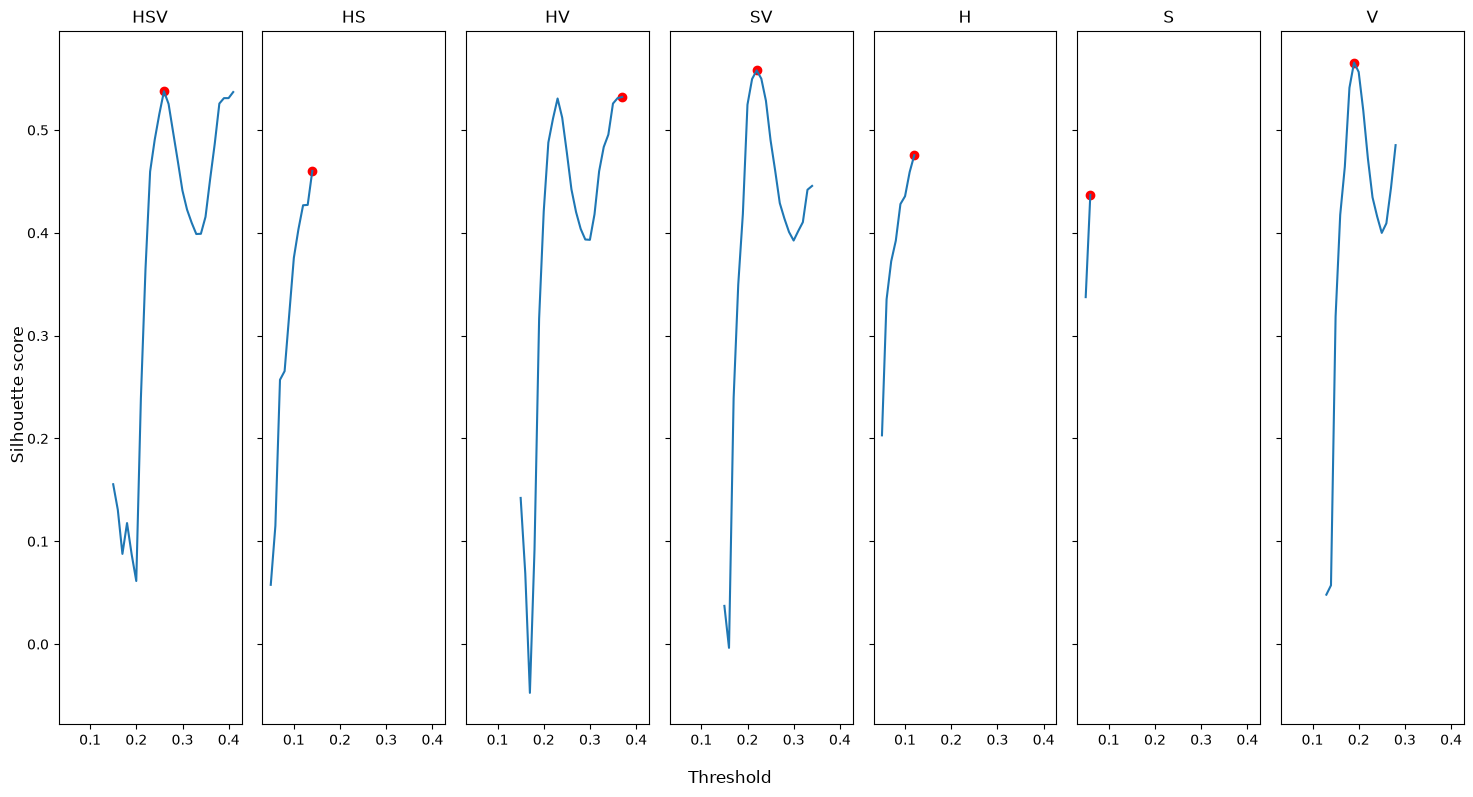

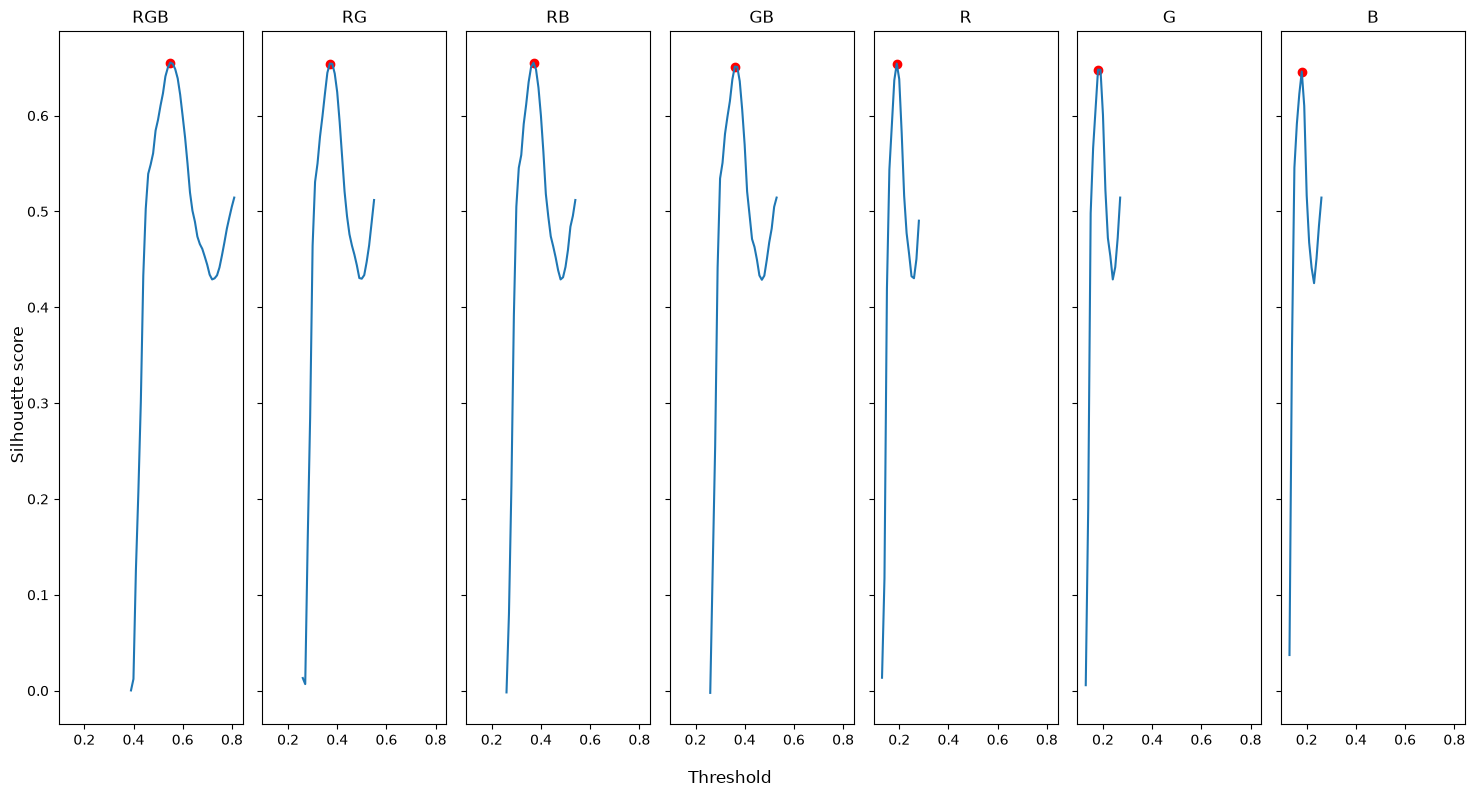

In [5]:

def remove_nans(thresholds, silhouette_scores):
    t_ = []
    s_ = []
    for ts, ss in zip(thresholds, silhouette_scores):
        if not np.isnan(ss):
            t_.append(ts)
            s_.append(ss)
    return np.array(t_), np.array(s_)

def silhouette_optimized_threshold(variations, title=None, make_plot=False):
    if make_plot: fig, axs=plt.subplots(1, 7, sharex=True, sharey=True, figsize=(15,8))
    optimal_thresholds = {}
    for i, variation in enumerate(variations.keys()):
        silhouette_scores = np.load(scan_output_dir / f"silhouette score pipe {variation}.npy")
        
        t, s = remove_nans(thresholds, silhouette_scores)
        optimal_thresholds[variation] = t[s == s.max()][0]
        print(f" {variation} optimal_threshold: {t[s == s.max()][0]}")
        if not make_plot: 
            continue
        ax = axs.flat[i]
        ax.plot(t, s)
        ax.set_title(variation)
        try:
            ax.scatter(t[s == s.max()], 
                    s[s == s.max()],
                    c="r")
        except Exception: pass
        # plt.close("all")
    if not make_plot: return optimal_thresholds

    fig.supxlabel("Threshold")
    fig.supylabel("Silhouette score")
    fig.tight_layout()
    fig.savefig(figure_dir / f"thresholds-silhouette {title}.png")
    return optimal_thresholds


thresholds = np.load(scan_output_dir / "thresholds pipe.npy")
HSV = np.load(scan_output_dir / "HSV pipe.npy")
RGB = np.load(scan_output_dir / "RGB pipe.npy")

H = HSV[:, 0]
S = HSV[:, 1]
V = HSV[:, 2]
R = RGB[:, 0]
G = RGB[:, 1]
B = RGB[:, 2]

HSV_variations = {
    "HSV": H+S+V,
    "HS": H+S,
    "HV": H+V,
    "SV": S+V,
    "H": H,
    "S": S,
    "V": V,
}
RGB_variations = {
    "RGB": R+G+B,
    "RG": R+G,
    "RB": R+B,
    "GB": G+B,
    "R": R,
    "G": G,
    "B": B,
}

optimal_thresholds_HSV = silhouette_optimized_threshold(HSV_variations, title="HSV pipe", make_plot=True)
optimal_thresholds_RGB = silhouette_optimized_threshold(RGB_variations, title="RGB pipe", make_plot=True)


/tmp/ipykernel_10978/3581802630.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


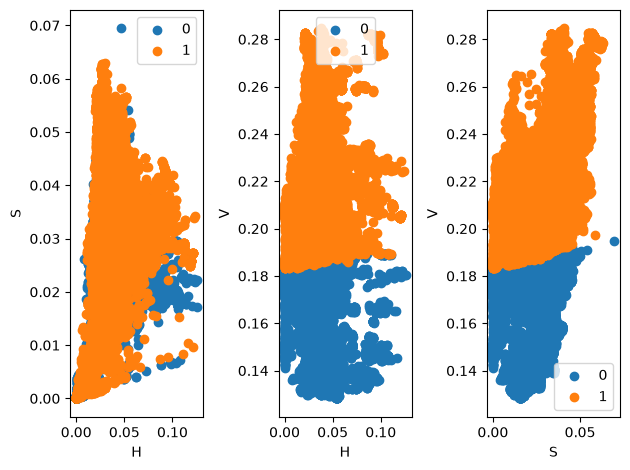

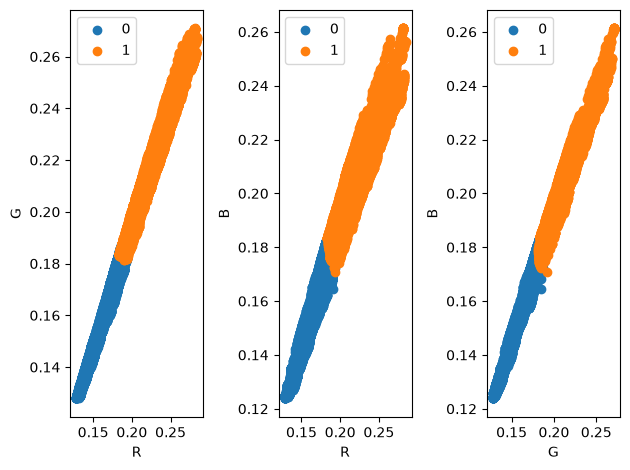

In [6]:

def pixel_rep_plot(HSV, condition, title):
    H = HSV[:, 0]
    S = HSV[:, 1]
    V = HSV[:, 2]
    labels = condition
    fig, axs=plt.subplots(1, 3)
    axs[0].scatter(H[labels==0], S[labels==0], c="tab:blue", label="0")
    axs[0].scatter(H[labels==1], S[labels==1], c="tab:orange", label="1")
    axs[1].scatter(H[labels==0], V[labels==0], c="tab:blue", label="0")
    axs[1].scatter(H[labels==1], V[labels==1], c="tab:orange", label="1")
    axs[2].scatter(S[labels==0], V[labels==0], c="tab:blue", label="0")
    axs[2].scatter(S[labels==1], V[labels==1], c="tab:orange", label="1")
    axs[0].set_xlabel(title[0]) # "H"
    axs[0].set_ylabel(title[1]) # "S"
    axs[1].set_xlabel(title[0]) # "H"
    axs[1].set_ylabel(title[2]) # "V"
    axs[2].set_xlabel(title[1]) # "S"
    axs[2].set_ylabel(title[2]) # "V"
    for ax in axs: ax.legend()
    fig.tight_layout()

variation = "RGB"
pixel_rep_plot(HSV, RGB_variations[variation] > optimal_thresholds_RGB[variation], title="HSV pipe")
pixel_rep_plot(RGB, RGB_variations[variation] > optimal_thresholds_RGB[variation], title="RGB pipe")

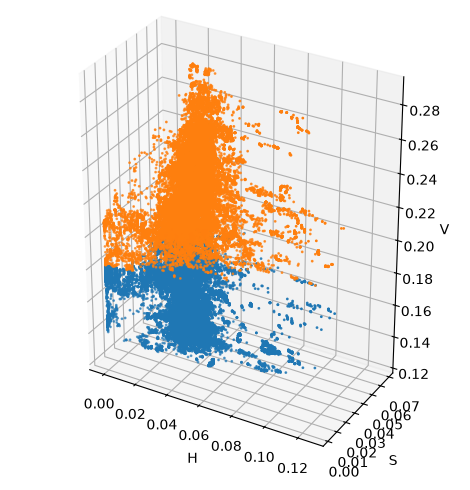

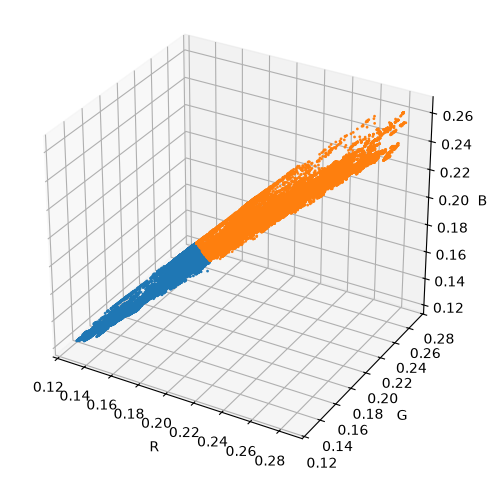

In [7]:
labels = RGB_variations[variation] > optimal_thresholds_RGB[variation]

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(H[labels==0],
           S[labels==0],
           V[labels==0], 
           s=1)
ax.scatter(H[labels==1],
           S[labels==1],
           V[labels==1], 
           s=1)
ax.set_xlabel('H')
ax.set_ylabel('S')
ax.set_zlabel('V')
ax.set_aspect("equal")
fig.tight_layout()
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(R[labels==0],
           G[labels==0],
           B[labels==0], 
           s=1)
ax.scatter(R[labels==1],
           G[labels==1],
           B[labels==1], 
           s=1)
ax.set_xlabel('R')
ax.set_ylabel('G')
ax.set_zlabel('B')
ax.set_aspect("equal")
fig.tight_layout()

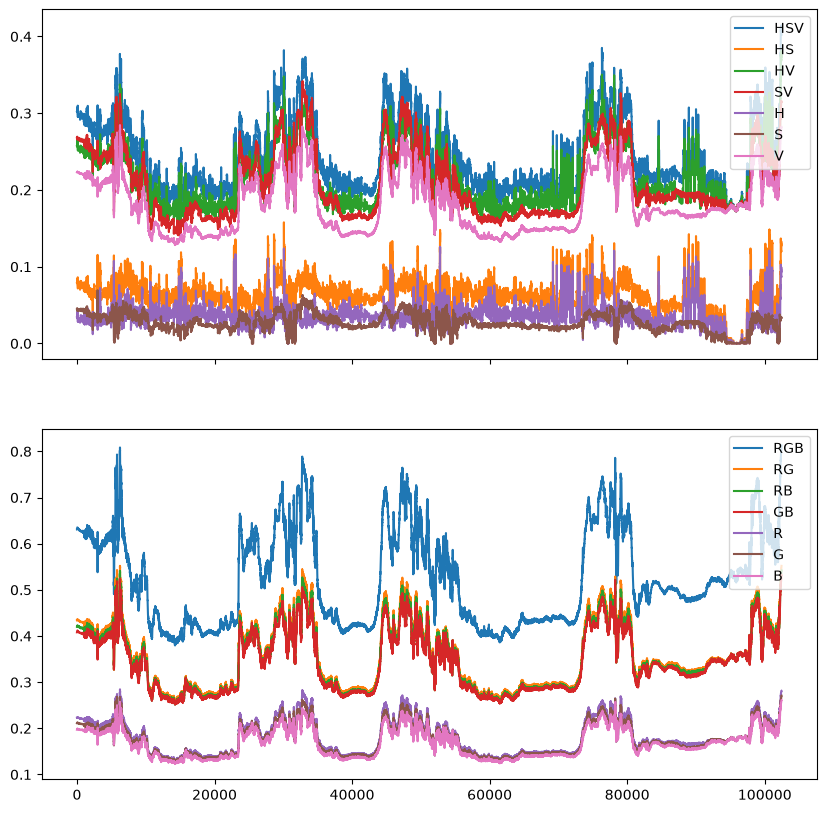

In [8]:
fig, axs=plt.subplots(2, 1, figsize=(10, 10), sharex=True)
for variation in HSV_variations: axs[0].plot(HSV_variations[variation], label=variation)
for variation in RGB_variations: axs[1].plot(RGB_variations[variation], label=variation)
for ax in axs: ax.legend()

centroids = array([[0.02026899],
       [0.0381415 ]])


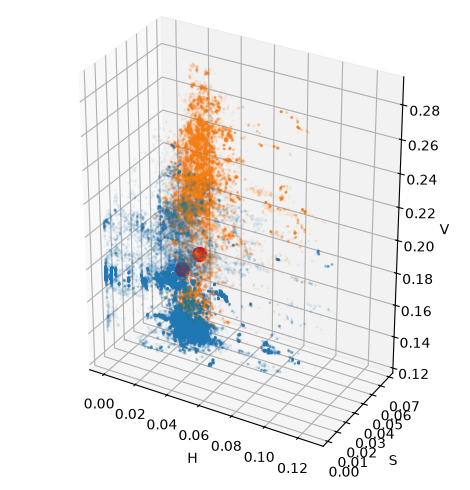

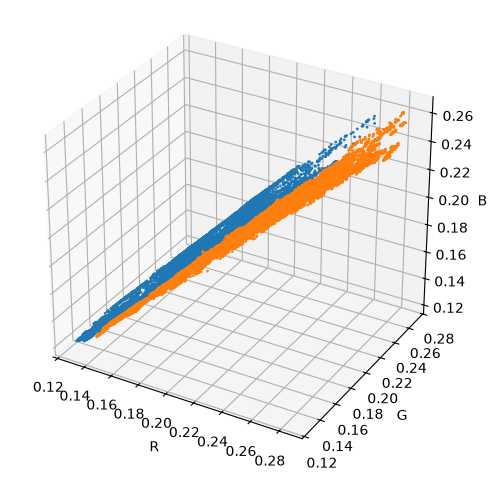

In [9]:
from sklearn.cluster import k_means

X = HSV
X = S.reshape((X.shape[0], -1))
centroids, labels, _ = k_means(X, n_clusters=2)

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(H[labels==0],
           S[labels==0],
           V[labels==0], 
           s=1, alpha=0.25)
ax.scatter(H[labels==1],
           S[labels==1],
           V[labels==1], 
           s=1, alpha=0.25)
print(f"{centroids = }")
ax.scatter(*(H.mean(), centroids[0], V.mean()), c="r", s=100)
ax.scatter(*(H.mean(), centroids[1], V.mean()), c="r", s=100)
ax.set_xlabel('H')
ax.set_ylabel('S')
ax.set_zlabel('V')
ax.set_aspect("equal")
fig.tight_layout()

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(R[labels==0],
           G[labels==0],
           B[labels==0], 
           s=1)
ax.scatter(R[labels==1],
           G[labels==1],
           B[labels==1], 
           s=1)
ax.set_xlabel('R')
ax.set_ylabel('G')
ax.set_zlabel('B')
ax.set_aspect("equal")
fig.tight_layout()

#### 3D manual findings

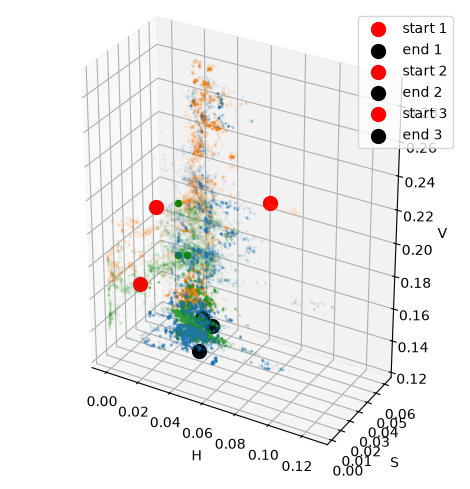

In [10]:
from manual_ice_container import results
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
for i in range(1, 4):
    ax.scatter(H[results[f"start{i}"]: results[f"end{i}"]],
               S[results[f"start{i}"]: results[f"end{i}"]],
               V[results[f"start{i}"]: results[f"end{i}"]], 
               s=1, alpha=0.25)
    ax.scatter(H[results[f"start{i}"]],
               S[results[f"start{i}"]],
               V[results[f"start{i}"]], 
               s=100, c="r", label=f"start {i}")
    ax.scatter(H[results[f"end{i}"]],
               S[results[f"end{i}"]],
               V[results[f"end{i}"]], 
               s=100, c="k", label=f"end {i}")

ax.scatter(H[results["start1"] - 2000],
           S[results["start1"] - 2000],
           V[results["start1"] - 2000], c="g")
ax.scatter(H[results["start2"] - 2000],
           S[results["start2"] - 2000],
           V[results["start2"] - 2000], c="g")
ax.scatter(H[results["start3"] - 2000],
           S[results["start3"] - 2000],
           V[results["start3"] - 2000], c="g")
theta = np.linspace(0, 2*np.pi, 100)
rs = 5
x0, y0, z0 = 7.5, 20, 15
x = np.linspace(-2.5, 2.5, len(theta)) + x0
thetas, xs = np.meshgrid(theta, x)
ys = rs*np.cos(thetas) + y0
zs = rs*np.sin(thetas) + z0
# ax.plot_surface(xs, ys, zs)

ax.legend()
ax.set_xlabel('H')
ax.set_ylabel('S')
ax.set_zlabel('V')
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(figure_dir / "3D manual.png")

In [11]:
# HSV = np.load(scan_output_dir / "HSV full cap.npy")
H = HSV[:, 0]
S = HSV[:, 1]
V = HSV[:, 2]
HL = 6
HU = 10
SL = 25
SU = 30
VL = 0
VU = 12
condition = (HL < H) & (H < HU) & (SL < S) & (S < SU) & (VL < V) & (V < VU)

indicies = np.where(condition)[0]
print(f"{len(indicies) = }")
# i = np.random.randint(0, len(indicies))
# idx = indicies[i]
# print(f"{idx = }")
# ret, frame = red.read()
# cv2.imwrite(figure_dir / "image.png", frame)

# set_frame(red, 0)
# i = 0
# while red.isOpened():
#     break
#     idx = indicies[i]
#     set_frame(red, idx)
#     ret, frame = red.read()
#     if not ret: break
#     cv2.imshow("..", frame)
#     key = cv2.waitKey(1)
#     if key == ord("q"):
#         break
#     if i == len(indicies) - 1:
#         break
#     i += 1
# cv2.destroyAllWindows()
# fig, ax = plt.subplots()
# ax.plot(indicies)

len(indicies) = 0


In [12]:

# fig = plt.figure()
# ax = fig.add_subplot(projection="3d")
# for i in range(1, 4):
#     ax.scatter(H,
#                S,
#                V, c="k")
# ax.set_xlabel('H')
# ax.set_ylabel('S')
# ax.set_zlabel('V')
# ax.set_aspect("equal")
# fig.tight_layout()
# fig.savefig(figure_dir / "3D manual.png")

### individual pixel trajectories


In [13]:
del HSV
del RGB
del fig


In [14]:
HSV = np.load(scan_output_dir / "HSV_pipe_cap_light.npy")
print(f"{HSV.shape = }")


HSV.shape = (10244, 1444, 3)


(10244, 1444)


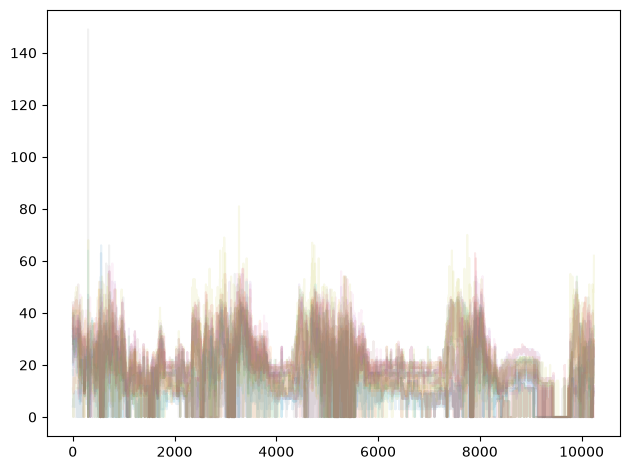

In [15]:
threshold = optimal_thresholds_HSV["S"]
indicies = np.arange(HSV.shape[0])
fig, ax=plt.subplots()
pixel_start, pixel_end = 0, HSV.shape[1]
channel = 1

under_mask = HSV[:, pixel_start:pixel_end, channel] < threshold
above_mask = HSV[:, pixel_start:pixel_end, channel] > threshold
print(under_mask.shape)
# ax.scatter(indicies[under_mask], HSV[:, pixel_start, channel][under_mask], s=1)
ax.plot(HSV[:, ::80, channel], alpha=0.1)
fig.tight_layout()

In [ ]:
pipe_mask = get_mask(cap, "pipe_small")
start = 25000
end = 40000
i = start
set_frame(cap, i)
under_history = []
above_history = []
while cap.isOpened():
    
    ret, frame = cap.read()
    if not ret: break

    cv2.imshow("Original", frame)
    frame = filter_frame(frame, pipe_mask)
    frame = change_color_representation(frame, cv2.COLOR_BGR2GRAY)
    cv2.imshow("Gray pipe", frame)

    
    print(f"{i}", end="\r")


    # n_under = under_mask[i//10,:].sum()
    # n_above = above_mask[i//10,:].sum()
    # under_history.append(n_under)
    # above_history.append(n_above)
    # fig, ax=plt.subplots()
    # ax.plot(under_history)
    # ax.plot(above_history)
    # fig.savefig(figure_dir / "history.png")
    # # print(f"{n_under = }")
    # # print(f"{n_above = }")
    # plt.close("all")

    i += 1

    key = cv2.waitKey(1)
    if key == ord("q"):
        break

    elif key == ord(" "):
        new_key = cv2.waitKey(0)
        if new_key == ord(" "):
            continue

    if i == end:
        break

cv2.destroyAllWindows()
    


In [17]:
stop

NameError: name 'stop' is not defined

In [ ]:
HSV = np.load(scan_output_dir / "HSV singular pixels cap.npy")
# RGB = np.load(scan_output_dir / "RGB singular pixels cap.npy")


In [ ]:
print(f"{HSV.shape = }")
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
for i in range(100, 500, 100):
    ax.scatter(HSV[:, i, 0],
               HSV[:, i, 1],
               HSV[:, i, 2])
ax.set_xlabel("H")
ax.set_ylabel("S")
ax.set_zlabel("V")

from time import sleep
for i in range(400, 20000, 10):
    fig, ax=plt.subplots()
    for j in range(100, 110):
        ax.scatter(HSV[i-100:i, j, 1],
                   HSV[i-100:i, j, 2],
                    s = 1)
        ax.scatter(HSV[i, j, 1],
                   HSV[i, j, 2],
                   s = 100)
                
    fig.suptitle(f"{i * 10}")
    fig.savefig(figure_dir / "pixel trajectories.png")
    plt.close("all")
    set_frame(cap, i*10)
    _, frame = cap.read()
    cv2.imwrite(figure_dir / "image.png", frame)
    sleep(1)

HSV.shape = (10243, 2579, 3)


[h264 @ 0x11c18580] Missing reference picture, default is 0
[h264 @ 0x11c18580] Missing reference picture, default is 0
[h264 @ 0x11c18580] Missing reference picture, default is 0
[h264 @ 0x11c18580] Missing reference picture, default is 0


KeyboardInterrupt: 

### Test iceness index method

threshold = 0.1


TypeError: Axes3D.scatter() missing 1 required positional argument: 'ys'

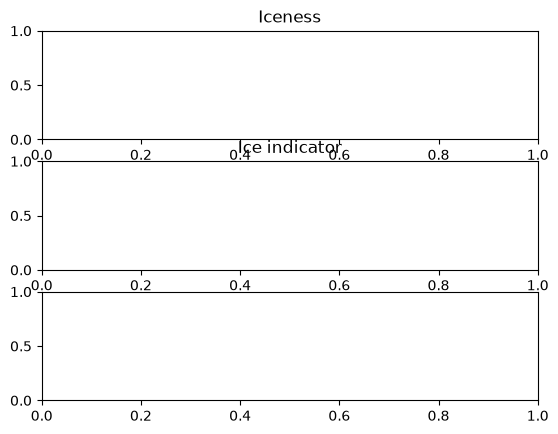

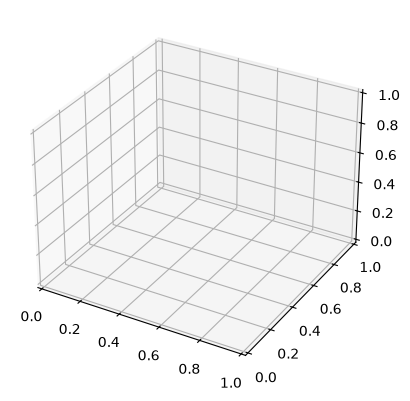

In [ ]:
variation = "S"
threshold = 0.1# optimal_thresholds[variation]
print(f"{threshold = }")

def live_tester(videocapture, mask, start):

    # open video at start
    i = start
    # cap.set(cv2.CAP_PROP_POS_FRAMES, i) # search up the frame
    videocapture.set(cv2.CAP_PROP_POS_FRAMES, i) # search up the frame
    ret, frame = cap.read()

    fig, axs=plt.subplots(3, 1)
    axs[0].set_title("Iceness")
    axs[1].set_title("Ice indicator")
    fig3d = plt.figure()
    ax3d = fig3d.add_subplot(projection="3d")
    ax3d.scatter(*centroids[0], c="r", s=100, label="k-means cluster centroids")
    ax3d.scatter(*centroids[1], c="r", s=100)
    ax3d.set_xlabel('H')
    ax3d.set_ylabel('S')
    ax3d.set_zlabel('V')
    plt.close("all")

    ice_history = []
    d0s = []
    d1s = []    
    hs = []
    ss = []
    vs = []
    while cap.isOpened():
        ret, frame = videocapture.read()
        if not ret:
            break

        cv2.imshow("..", frame)

        # filter the frame and normalize it
        frame = frame * mask[:, :, None]

        rgb  = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        hsv  = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        r = rgb[:,:, 0].mean()
        g = rgb[:,:, 1].mean()
        b = rgb[:,:, 2].mean()
        h = hsv[:,:, 0].mean()
        s = hsv[:,:, 1].mean()
        v = hsv[:,:, 2].mean()

        # normalize
        # frame_filtered = normalize_brightness(frame_filtered, mask)

        iceness = s
        d0 = np.linalg.norm(hsv - centroids[0])
        d1 = np.linalg.norm(hsv - centroids[1])

        isice = d0 < d1

        d0s.append(d0)
        d1s.append(d1)
        ice_history.append(isice * 1.0 if isice else 0.0) 
        hs.append(h)
        ss.append(s)
        vs.append(v)

        axs[0].plot(ice_history, c="k")
        axs[1].plot(d0s, c="k")
        axs[2].plot(d1s, c="k")

        ax3d.scatter(hs, ss, vs, c="k")
        
        fig.savefig(figure_dir / "icenss.png")
        fig3d.savefig(figure_dir / "3dHSV.png")

        key = cv2.waitKey(1)
        if key == ord("q"):
            break

        if key == ord("i"):
            for i in range(len(axs)):
                axs[i].axvline(len(ice_history)-1)

        elif key == ord(" "):
            k = cv2.waitKey(0)
            if k == ord(" "):
                continue
            elif k == ord("q"):
                break
        increase = 100
        for _ in range(increase - 1):
            # grab but dont decode
            videocapture.grab()


        i += increase
    cv2.destroyAllWindows()
    return fig3d, ax3d
    
fig3d, ax3d = live_tester(red, red_mask, 0)

In [ ]:
def live_tester(videocapture, mask, start):

    # open video at start
    i = start
    # cap.set(cv2.CAP_PROP_POS_FRAMES, i) # search up the frame
    videocapture.set(cv2.CAP_PROP_POS_FRAMES, i) # search up the frame
    ret, frame = cap.read()

    fig, axs=plt.subplots(3, 1)
    axs[0].set_title("Iceness")
    axs[1].set_title("Ice indicator")
    fig3d = plt.figure()
    ax3d = fig3d.add_subplot(projection="3d")
    ax3d.scatter(*centroids[0], c="r", s=100, label="k-means cluster centroids")
    ax3d.scatter(*centroids[1], c="r", s=100)
    ax3d.set_xlabel('H')
    ax3d.set_ylabel('S')
    ax3d.set_zlabel('V')
    plt.close("all")

    ice_history = []
    d0s = []
    d1s = []    
    hs = []
    ss = []
    vs = []
    while cap.isOpened():
        ret, frame = videocapture.read()
        if not ret:
            break

        cv2.imshow("..", frame)

        # filter the frame and normalize it
        frame = frame * mask[:, :, None]

        rgb  = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        hsv  = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        r = rgb[:,:, 0].mean()
        g = rgb[:,:, 1].mean()
        b = rgb[:,:, 2].mean()
        h = hsv[:,:, 0].mean()
        s = hsv[:,:, 1].mean()
        v = hsv[:,:, 2].mean()

        # normalize
        # frame_filtered = normalize_brightness(frame_filtered, mask)

        iceness = s
        d0 = np.linalg.norm(hsv - centroids[0])
        d1 = np.linalg.norm(hsv - centroids[1])

        isice = d0 < d1

        d0s.append(d0)
        d1s.append(d1)
        ice_history.append(isice * 1.0 if isice else 0.0) 
        hs.append(h)
        ss.append(s)
        vs.append(v)

        axs[0].plot(ice_history, c="k")
        axs[1].plot(d0s, c="k")
        axs[2].plot(d1s, c="k")

        ax3d.scatter(hs, ss, vs, c="k")
        
        fig.savefig(figure_dir / "icenss.png")
        fig3d.savefig(figure_dir / "3dHSV.png")

        key = cv2.waitKey(1)
        if key == ord("q"):
            break

        if key == ord("i"):
            for i in range(len(axs)):
                axs[i].axvline(len(ice_history)-1)

        elif key == ord(" "):
            k = cv2.waitKey(0)
            if k == ord(" "):
                continue
            elif k == ord("q"):
                break
        increase = 100
        for _ in range(increase - 1):
            # grab but dont decode
            videocapture.grab()


        i += increase
    cv2.destroyAllWindows()A
    return fig3d, ax3d
    
fig3d, ax3d = live_tester(red, red_mask, 0)

In [ ]:
stop

NameError: name 'stop' is not defined

## Legacy

### Frame histograms 

In [ ]:
from video import normalize_brightness
# define bins used for all histograms
bins = np.arange(0, 256, 5)


def channel_histogram(pixels, density=True):
    # get counts (density)
    counts_blue, _ = np.histogram(pixels[:, 0], bins, density=density)
    counts_green, _ = np.histogram(pixels[:, 1], bins, density=density)
    counts_red, _ = np.histogram(pixels[:, 2], bins, density=density)
    return counts_blue, counts_green, counts_red

def plot_frame_and_histogram(frame, histograms):

    ch1, ch2, ch3 = histograms

    fig, axs=plt.subplots(3, 1)

    axs[0].plot(bins[:-1], ch1)
    axs[1].plot(bins[:-1], ch2)
    axs[2].plot(bins[:-1], ch3)

    axs[0].set_title("blue", c="blue")
    axs[1].set_title("green", c="green")
    axs[2].set_title("red", c="red")
    fig.tight_layout()

    fig.savefig(figure_dir / "histogram.png")
    plt.close()

    # write the frame itself
    cv2.imwrite(figure_dir / "image.png", frame)



def frame_histogram(videocapture, target_frame_index, mask, savefigs=True, searchup=True):
    """
    load a particular frame index in the video capture
    """
    if searchup:
        set_frame(videocapture, target_frame_index)

    ret, frame = cap.read()

    if not ret:
        return 

    frame_filtered = filter_frame(frame, mask)
    frame_filtered = normalize_brightness(frame_filtered, mask)
    valid_pixels = extract_pixels_in_mask(frame_filtered, mask)


    histograms = channel_histogram(valid_pixels, density=True)
    counts_blue, counts_green, counts_red = histograms

    if savefigs:
        plot_frame_and_histogram(frame_filtered, histograms)
    
    return {
        "counts_blue": counts_blue,
        "counts_green": counts_green,
        "counts_red": counts_red,
    }

# target_frame = 10000
# target_frame = 4000
target_frame = 1000
histogram_dict = frame_histogram(cap, target_frame, mask, savefigs=0)

### Manually specified ice / noice regions 

In [ ]:
# the following loops have been used to establish a ice and a no-ice area
target_frame = 10000 - 1000
for addition in range(0, 10000, 10):
    break    
    extract_im_and_hist(cap, target_frame+addition, mask)
    time.sleep(0.05)

target_frame = 0
for addition in range(0, 5000, 100):
    break
    extract_im_and_hist(cap, target_frame+addition, mask=np.ones(frame_shape))
    time.sleep(0.1)

icing_frames = 10000-1000, 10000-1000 + 10000
noicing_frames = 0, 5000

### Segmentation model 

#### Segment Anything Model (SAM)

In [ ]:
# from sam import load_sam

# model = load_sam()
# print(model)
# import requests
# import torch
# from PIL import Image

# from transformers import SamModel, SamProcessor

# model = SamModel.from_pretrained("facebook/sam-vit-base", device_map="auto")
# processor = SamProcessor.from_pretrained("facebook/sam-vit-base")

# img_url = "https://huggingface.co/ybelkada/segment-anything/resolve/main/assets/car.png"
# raw_image = Image.open(requests.get(img_url, stream=True).raw).convert("RGB")
# input_points = [[[450, 600]]]  # 2D location of a window in the image

# inputs = processor(raw_image, input_points=input_points, return_tensors="pt").to(model.device)
# with torch.no_grad():
#     outputs = model(**inputs)

# masks = processor.image_processor.post_process_masks(
#     outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu()
# )
# scores = outputs.iou_scores
# masks = processor.image_processor.post_process_masks(
#     outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu()
# )
# scores = outputs.iou_scores

#### SegNet

In [ ]:
# get and image from the video
set_frame(cap, 0)
ret, frame = cap.read()
if not ret: print("Error")
image = torch.tensor(frame)
image = image.to(torch.float32) / 255.0
image = image.unsqueeze(0)
image = image.permute(0, 3, 1, 2)
print(f"{image.shape = }")



image.shape = torch.Size([1, 3, 720, 1280])


In [ ]:
out = torch.load(segnet_output_dir / "out")
out = out.squeeze(0)
out = out.permute(1, 2, 0)
out = (out * 255).to(torch.uint8)
out = out.cpu().detach().numpy()


In [ ]:
print(f"{out.shape = }")
frame = out[:, :, 0]
print(f"{frame.shape = }")
print(frame)
cv2.imwrite(figure_dir / "SegNet output.png", frame)

out.shape = (360, 640, 2)
frame.shape = (360, 640)
[[138 151 154 ... 141 102 133]
 [152 141 169 ... 144 143 141]
 [172 150 161 ... 153 169 160]
 ...
 [148 136 154 ... 134 151 141]
 [148 153 154 ... 161 168 146]
 [153 141 171 ... 151 147 149]]


True

### Analyze case seperation indicies

frame_indicies_ice.shape = (59533,)
frame_indicies_noice.shape = (42903,)


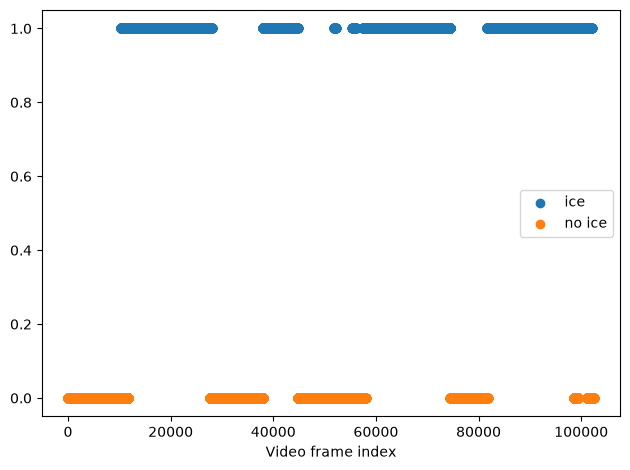

In [ ]:
frame_indicies_ice = np.load(case_videos_dir / "frame_indicies_ice.npy")
frame_indicies_noice = np.load(case_videos_dir / "frame_indicies_noice.npy")

print(f"{frame_indicies_ice.shape = }")
print(f"{frame_indicies_noice.shape = }")

fig, ax=plt.subplots()
ax.scatter(frame_indicies_ice, np.ones_like(frame_indicies_ice), label="ice")
ax.scatter(frame_indicies_noice, np.zeros_like(frame_indicies_noice), label="no ice")
ax.set_xlabel("Video frame index")
ax.legend(); fig.tight_layout()


### Use iceness index to split video into ice / no-ice

Using the regions of interest, we should be able to split the original video into two videos 

In [ ]:
output_icing_path = outputvideos_dir / ("icing_" + video_filename)
output_noicing_path = outputvideos_dir / ("noicing_" + video_filename)
split_video_into_ice_noice = 0


def split_into_ice_noice(videocapture, output_icing, output_noicing, increase=100, num_frames = 1000, ):
    # open video at beginning 
    i = 0
    videocapture.set(cv2.CAP_PROP_POS_FRAMES, i) # search up the frame
    ret, frame = cap.read()

    frame_indicies_ice = []
    frame_indicies_noice = []

    num_dp = 1
    while cap.isOpened():

        ret, frame = videocapture.read()
        if not ret:
            break

        frame_filtered = frame * mask[:, :, None]

        frame_filtered_normalized = normalize_brightness(frame_filtered)

        _, isice = icenessindex(frame_filtered_normalized)

        if isice:
            output_icing.write(frame)
            frame_indicies_ice.append(i)
        else:
            output_noicing.write(frame)
            frame_indicies_noice.append(i)


        if num_dp == num_frames and num_frames:
            break

        for _ in range(increase):
            videocapture.grab()
        num_dp += 1
        i += increase

    output_icing.release()
    output_noicing.release()
    cv2.destroyAllWindows()
    frame_indicies_ice = np.array(frame_indicies_ice)
    frame_indicies_noice = np.array(frame_indicies_noice)
    np.save(outputvideos_dir / "frame_indicies_ice.npy", frame_indicies_ice)
    np.save(outputvideos_dir / "frame_indicies_noice.npy", frame_indicies_noice)

if split_video_into_ice_noice:

    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    ret, frame = cap.read()
    frame_shape = frame.shape
    width, height = frame_shape[1], frame_shape[0]
    # from
    # https://learnopencv.com/reading-and-writing-videos-using-opencv/
    output_icing = cv2.VideoWriter(output_icing_path,
                                cv2.VideoWriter_fourcc(*'XVID'), 20, (width, height))
    output_noicing = cv2.VideoWriter(output_noicing_path,
                                    cv2.VideoWriter_fourcc(*'XVID'), 20, (width, height))

    split_into_ice_noice(cap, output_icing, output_noicing, 100, 0)




NameError: name 'outputvideos_dir' is not defined

In [ ]:
frame_indicies_ice = np.load(outputvideos_dir / "frame_indicies_ice.npy")
frame_indicies_noice = np.load(outputvideos_dir / "frame_indicies_noice.npy")

In [ ]:
show_noicing = 0
show_icing = 0


cap_noicing = cv2.VideoCapture(output_noicing_path)
cap_icing = cv2.VideoCapture(output_icing_path)

total_frames_noicing = int(cap_noicing.get(cv2.CAP_PROP_FRAME_COUNT))
total_frames_icing = int(cap_icing.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"{total_frames_noicing = }")
print(f"{total_frames_icing = }")

cap_noicing.set(cv2.CAP_PROP_POS_FRAMES, 0)


def show_noicing_video():
    while cap_noicing.isOpened():
        ret, frame = cap_noicing.read()

        if not ret:
            break

        cv2.imshow("No Icing", frame)

        key = cv2.waitKey(0)
        if key == ord("q"):
            break

def show_icing_video():
    cap_icing.set(cv2.CAP_PROP_POS_FRAMES, 0)
    i = 0
    while cap_icing.isOpened():
        ret, frame = cap_icing.read()

        if not ret:
            break

        # if i == total_frames_icing // 2:
        #     break

        cv2.imshow("Icing", frame)

        key = cv2.waitKey(0)
        if key == ord("q"):
            break
        i+=1


if show_noicing:
    show_noicing_video()
if show_icing:
    show_icing_video()



total_frames_noicing = -1
total_frames_icing = -1


In [ ]:
cap_ice = cv2.VideoCapture(output_icing_path)
total_frames_ice = int(cap_ice.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Loaded video with {total_frames_ice} frames")

Loaded video with -1 frames


In [ ]:
print(f"{mask.shape = }")
mask_height, mask_width = mask.shape
# make an array of all the pixels with ice
n_frames = 629//2
pixels_ice = np.zeros((n_frames, mask.sum(), 3), dtype=np.uint8)
cap_ice.set(cv2.CAP_PROP_POS_FRAMES, 0)   
i = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break    
    frame = frame * mask[:, :, None]   
    frame = normalize_brightness(frame, mask)
    pixels = frame[mask==1]
    pixels_ice[i, :, 0] = pixels[:, 0]
    pixels_ice[i, :, 1] = pixels[:, 1]
    pixels_ice[i, :, 2] = pixels[:, 2]

    if i == n_frames - 1:
        break
    i += 1


pixels_ice = np.array(pixels_ice)#.reshape((-1, 3))
pixels_ice_flat = pixels_ice.reshape((n_frames, -1))
sample_size = pixels_ice.shape[1]


mask.shape = (720, 1280)


In [ ]:
n_components = 2
ipca = IncrementalPCA(n_components)
ipca.fit(pixels_ice_flat)

KeyboardInterrupt: 

In [ ]:
components = ipca.components_.reshape((n_components, sample_size, 3))
print(f"{components.shape = }")


In [ ]:
reduced = ipca.transform(pixels_ice_flat)


In [ ]:

print(f"{reduced.shape = }")
fig, ax = plt.subplots()
ax.scatter(reduced[:-len(reduced[:, 0])//2, 0], 
           reduced[:-len(reduced[:, 0])//2, 1], label="First quater")
ax.scatter(reduced[len(reduced[:, 0])//2:, 0], 
           reduced[len(reduced[:, 0])//2:, 1], label="second quater")
ax.legend()